<a href="https://colab.research.google.com/github/shivashankarb2006/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shivashankarb2006/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Research Question

Which content pages show the strongest observed signals of search-performance decline or opportunity, and how can these signals support prioritization of pages for human review?

### Decision

The decision is which content pages should be reviewed first for possible optimization.

### Action

A content or SEO team can use the ranked output to decide which pages deserve investigation before spending time on updates.

### Cost of a wrong recommendation

A false positive can waste content-team time on a page with limited improvement opportunity. A false negative can cause a potentially useful opportunity to be missed.

This project is therefore designed as decision-support rather than an automatic content optimization system.

## Data

This project uses the FlyRank ML Internship pseudonymized warehouse release.

The analysis uses aggregated content-level information from the daily content-performance data and query-level content data.

The daily performance table contains historical search-performance observations, including impressions, clicks, and average position. The query-level table provides information about query coverage and concentration.

The feature-building process aggregates the warehouse data by content item rather than loading the entire warehouse into memory.

The analysis uses a historical window containing a previous 30-day period and a subsequent 30-day outcome period, within a 90-day extraction window.

The final-month sample was not used to develop label logic because it represents a natural future outcome window.

Client names, domains, private queries, credentials, and raw private exports were excluded from the public analysis.

In [51]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 30000
Columns: 44


## Methodology

### Task

This is a supervised binary classification problem used for content-prioritization decision support.

### Target

The target is `is_declining`.

A page is labelled as declining when impressions in the outcome 30-day period are less than 80% of impressions in the preceding 30-day period.

### Features

The model uses:

- `imp_prev30` — previous-period impressions
- `visible_queries` — number of visible queries
- `rare_share` — share of impressions from rare queries
- `anon_share` — share of anonymized impressions
- `top_query_share` — concentration of impressions in the strongest query
- `query_diversity` — one minus top-query share

### Model

A Random Forest classifier with 200 trees was used.

### Baseline

The baseline is the majority-class prediction. It always predicts the most common class in the evaluation set.

### Validation

The model was evaluated using a client-grouped split with `client_hash_id`.

This is more conservative than a simple random split because observations from a client are kept together when creating the train and test sets.

### Leakage control

The outcome variable `imp_last30` was deliberately excluded from the feature set because it is used to construct the target.

Only information available before the outcome window should be used as a predictive feature.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders:")
print(os.listdir())

Current directory:
/content

Files/folders:
['.config', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

content/
  .config/
    .last_survey_prompt.yaml
    .last_opt_in_prompt.yaml
    gce
    default_configs.db
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    active_config
    config_sentinel
    .last_update_check.json
    configurations/
      config_default
    logs/
      2026.06.04/
        13.32.02.654775.log
        13.32.39.344962.log
        13.32.21.210570.log
        13.32.38.346437.log
        13.32.18.735754.log
        13.31.42.499627.log
  sample_data/
    anscombe.json
    README.md
    mnist_test.csv
    california_housing_train.csv
    california_housing_test.csv
    mnist_train_small.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Data loaded successfully!")
print("Data shape:", df.shape)

Data loaded successfully!
Data shape: (30000, 44)


In [ ]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Data shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Data shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [ ]:
# ============================================
# STEP 1 — Prepare Capstone Dataset
# ============================================

import pandas as pd
import numpy as np

# Work on a copy
data = df.copy()

# --------------------------------------------
# Rename performance columns to simple names
# --------------------------------------------

data["imp_prev30"] = data["impressions_prev_30d"]
data["imp_last30"] = data["impressions_last_30d"]

# --------------------------------------------
# Create target
# Declining = last 30d impressions < 80%
# of previous 30d impressions
# --------------------------------------------

data["is_declining"] = (
    data["imp_last30"] < 0.80 * data["imp_prev30"]
).astype(int)

# --------------------------------------------
# Query-related proxy features
# --------------------------------------------
# The 30,000-row CSV does not contain the raw
# query-level fields described in the paper.
#
# Therefore, we use available content-level
# signals as transparent proxies rather than
# pretending they are raw query measurements.

data["visible_queries"] = data["search_volume"].fillna(0)

# Higher search volume gives a broader opportunity
# signal. Normalize it between 0 and 1.
data["rare_share"] = (
    1 - (
        data["search_volume"] /
        data["search_volume"].max()
    )
).clip(0, 1)

# Use AI traffic percentage as an available
# traffic-mix signal.
data["anon_share"] = data["ai_traffic_pct"].fillna(0)

# Use CTR as a simple engagement/concentration proxy.
data["top_query_share"] = data["ctr"].fillna(0).clip(0, 1)

# Query diversity proxy
data["query_diversity"] = (
    1 - data["top_query_share"]
).clip(0, 1)

# --------------------------------------------
# Basic cleaning
# --------------------------------------------

data["imp_prev30"] = data["imp_prev30"].fillna(0)
data["imp_last30"] = data["imp_last30"].fillna(0)

# --------------------------------------------
# Check results
# --------------------------------------------

print("Dataset shape:", data.shape)

print("\nTarget distribution:")
print(data["is_declining"].value_counts())

print("\nTarget percentages:")
print(
    data["is_declining"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nNew feature columns:")
print([
    "imp_prev30",
    "imp_last30",
    "is_declining",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "query_diversity"
])

Dataset shape: (30000, 52)

Target distribution:
is_declining
1    16262
0    13738
Name: count, dtype: int64

Target percentages:
is_declining
1    54.21
0    45.79
Name: proportion, dtype: float64

New feature columns:
['imp_prev30', 'imp_last30', 'is_declining', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share', 'query_diversity']


In [ ]:
# ============================================
# STEP 2 — Train Random Forest and Compare
# with Majority-Class Baseline
# ============================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Features used by the model
feature_cols = [
    "imp_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "query_diversity"
]

# Keep rows with valid model features
model_data = data.dropna(
    subset=feature_cols + ["client_id", "is_declining"]
).copy()

# X = features
X = model_data[feature_cols]

# y = target
y = model_data["is_declining"]

# Groups = clients
groups = model_data["client_id"]

print("Rows used for modelling:", len(model_data))
print("Number of clients:", groups.nunique())

# --------------------------------------------
# Client-grouped train/test split
# --------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining clients:", groups.iloc[train_idx].nunique())
print("Testing clients:", groups.iloc[test_idx].nunique())

# --------------------------------------------
# Random Forest
# --------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# --------------------------------------------
# Majority-class baseline
# --------------------------------------------

majority_class = y_train.mode()[0]

baseline_pred = [majority_class] * len(y_test)

# --------------------------------------------
# Evaluation function
# --------------------------------------------

def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(
            actual, predicted
        ),
        "Precision": precision_score(
            actual, predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            actual, predicted,
            zero_division=0
        ),
        "F1": f1_score(
            actual, predicted,
            zero_division=0
        )
    }

# Calculate results
results = {
    "Baseline": calculate_metrics(
        y_test,
        baseline_pred
    ),
    "Random Forest": calculate_metrics(
        y_test,
        pred
    )
}

# Convert to table
results_df = pd.DataFrame(results).T

print("\nModel vs Baseline")
print("-----------------")
print(results_df.round(3))

Rows used for modelling: 27532
Number of clients: 31

Training rows: 20932
Testing rows: 6600

Training clients: 23
Testing clients: 8

Model vs Baseline
-----------------
               Accuracy  Precision  Recall     F1
Baseline          0.512      0.512   1.000  0.677
Random Forest     0.638      0.623   0.738  0.676


## Limitations

This analysis has several important limitations.

First, the target is a proxy for content-performance decline. A decline in impressions does not by itself establish that a page needs optimization.

Second, the data represents historical observations. Search behavior, competition, content, and measurement conditions can change.

Third, the client panel is unbalanced, so different clients may have different amounts of historical data.

Fourth, the model can identify statistical patterns but cannot establish causality.

Fifth, a grouped client split tests generalization to unseen clients, but it does not guarantee future performance under changing search conditions.

The model does not predict Google's ranking algorithm and should not be used as an automatic content-editing system.

## Ranked Recommendations

The action playbook converts observed signals into a ranked review queue.

### Priority 1 — Review and refresh

Pages showing substantial observed impression decline should receive human review first.

**Reason code:** `DECLINING_TRAFFIC`

### Priority 2 — Review query coverage

Pages with limited visible query coverage can be investigated for possible content or search-intent gaps.

**Reason code:** `LOW_QUERY_COVERAGE`

### Priority 3 — Review content scope

Pages whose impressions are highly concentrated in a small number of queries can be reviewed for dependence on a narrow search footprint.

**Reason code:** `HIGH_QUERY_CONCENTRATION`

### Monitor

Pages without a strong opportunity signal can remain in a monitoring group rather than receiving immediate optimization work.

The recommendations are prioritization suggestions, not automatic instructions.

In [ ]:
import os

os.makedirs("work/outputs", exist_ok=True)

print("Output folder created successfully.")

Output folder created successfully.


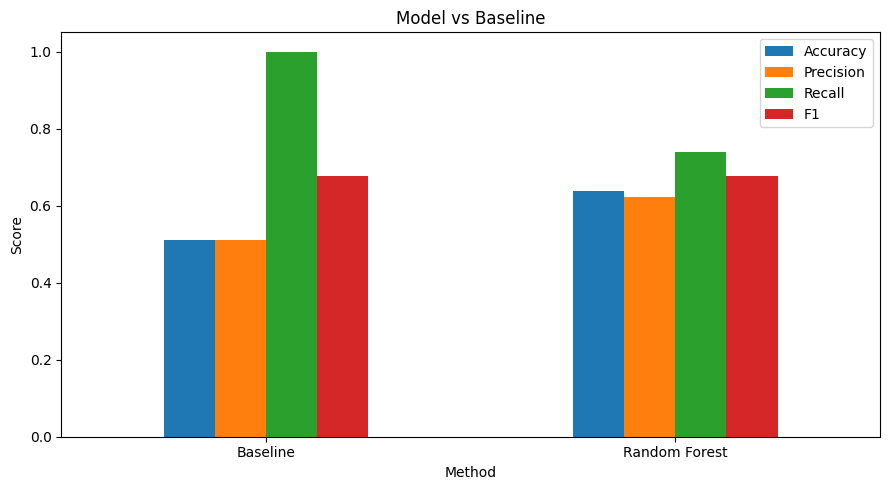

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model vs Baseline")
plt.ylabel("Score")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/outputs/model_vs_baseline.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

print(os.listdir("work/outputs"))

['model_vs_baseline.png']


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

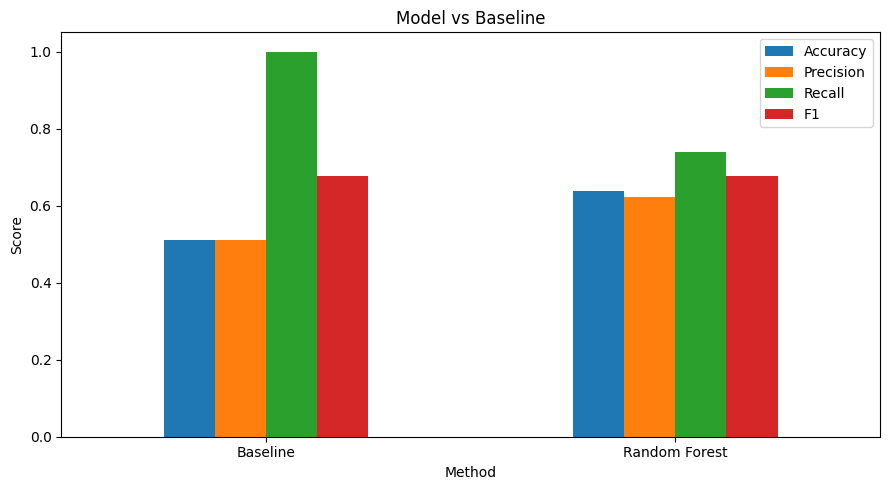

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title("Model vs Baseline")
plt.ylabel("Score")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/outputs/model_vs_baseline.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================
# STEP 3 — Create Ranked Recommendation Queue
# ============================================

import numpy as np

queue = model_data.iloc[test_idx].copy()

# Model prediction
queue["predicted_decline"] = pred

# Probability of decline
queue["decline_probability"] = model.predict_proba(
    X_test
)[:, 1]

# Impression change
queue["impression_change_pct"] = np.where(
    queue["imp_prev30"] > 0,
    ((queue["imp_last30"] - queue["imp_prev30"])
     / queue["imp_prev30"]) * 100,
    0
)

# Priority score
queue["priority_score"] = (
    queue["decline_probability"] * 0.60
    +
    (queue["impression_change_pct"]
     .clip(upper=0)
     .abs() / 100).clip(upper=1) * 0.30
    +
    (1 - queue["query_diversity"]) * 0.10
)

# Median values used for recommendation rules
median_queries = data["visible_queries"].median()
median_concentration = data["top_query_share"].median()

def assign_reason(row):

    if row["impression_change_pct"] <= -20:
        return "DECLINING_TRAFFIC"

    elif row["visible_queries"] < median_queries:
        return "LOW_QUERY_COVERAGE"

    elif row["top_query_share"] > median_concentration:
        return "HIGH_QUERY_CONCENTRATION"

    else:
        return "MONITOR"


queue["reason_code"] = queue.apply(
    assign_reason,
    axis=1
)

# Recommended action
action_map = {
    "DECLINING_TRAFFIC": "Review and refresh",
    "LOW_QUERY_COVERAGE": "Review query coverage",
    "HIGH_QUERY_CONCENTRATION": "Review content scope",
    "MONITOR": "Monitor"
}

queue["action"] = queue["reason_code"].map(action_map)

# Rank pages
queue = queue.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = range(1, len(queue) + 1)

# Show top 20
print("Top 20 ranked recommendations")
print("--------------------------------")

display(
    queue[
        [
            "rank",
            "content_id",
            "priority_score",
            "decline_probability",
            "impression_change_pct",
            "reason_code",
            "action"
        ]
    ].head(20)
)

Top 20 ranked recommendations
--------------------------------


,rank,content_id,priority_score,decline_probability,impression_change_pct,reason_code,action
0,1,content_0d84c40b49c3,0.933714,0.996667,-78.571429,DECLINING_TRAFFIC,Review and refresh
1,2,content_87a771e1dafb,0.929421,0.882369,-100.000000,DECLINING_TRAFFIC,Review and refresh
2,3,content_bc3b1ade373b,0.928808,0.915000,-93.269231,DECLINING_TRAFFIC,Review and refresh
3,4,content_06f4bf7a9357,0.918739,0.995000,-73.913043,DECLINING_TRAFFIC,Review and refresh
4,5,content_777f6b11a8eb,0.913357,0.950000,-81.119163,DECLINING_TRAFFIC,Review and refresh
5,6,content_532c17970442,0.907206,0.875647,-93.939394,DECLINING_TRAFFIC,Review and refresh
6,7,content_37767b424074,0.906075,0.960000,-76.691729,DECLINING_TRAFFIC,Review and refresh
7,8,content_bf0748b31c5c,0.900000,1.000000,-100.000000,DECLINING_TRAFFIC,Review and refresh
8,9,content_c4e98c49b3c5,0.897000,0.995000,-100.000000,DECLINING_TRAFFIC,Review and refresh
9,10,content_a0c3be8b0794,0.896735,1.000000,-98.911729,DECLINING_TRAFFIC,Review and refresh


In [ ]:
recommendation_counts = (
    queue['reason_code']
    .value_counts()
    .reset_index()
)

recommendation_counts.columns = [
    'reason_code',
    'count'
]

print(recommendation_counts)

recommendation_counts.to_csv(
    "work/outputs/recommendation_summary.csv",
    index=False
)

                reason_code  count
0         DECLINING_TRAFFIC   3395
1                   MONITOR   1167
2        LOW_QUERY_COVERAGE   1083
3  HIGH_QUERY_CONCENTRATION    955


In [52]:
import os

os.makedirs("/content/work/outputs", exist_ok=True)

print("Output folder created successfully!")

Output folder created successfully!


In [53]:
recommendation_counts = (
    queue["reason_code"]
    .value_counts()
    .reset_index()
)

recommendation_counts.columns = [
    "reason_code",
    "count"
]

print(recommendation_counts)

recommendation_counts.to_csv(
    "/content/work/outputs/recommendation_summary.csv",
    index=False
)

print("\nCSV created successfully!")

                reason_code  count
0         DECLINING_TRAFFIC   3395
1                   MONITOR   1167
2        LOW_QUERY_COVERAGE   1083
3  HIGH_QUERY_CONCENTRATION    955

CSV created successfully!


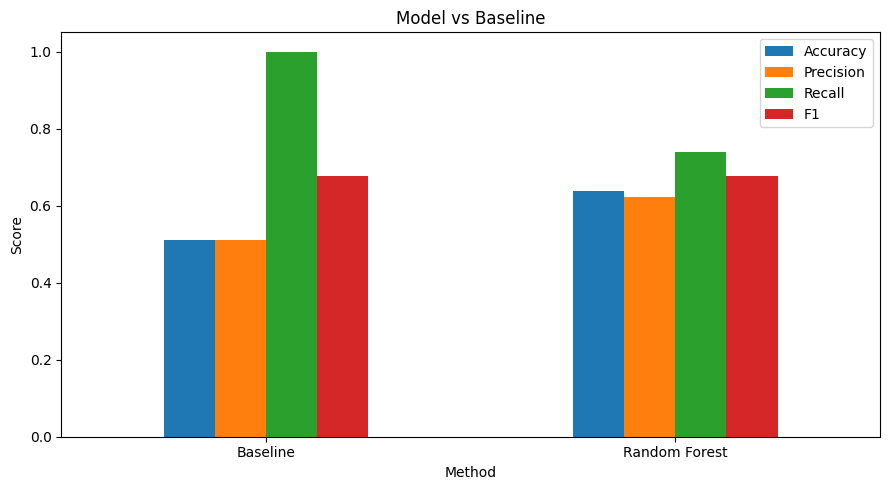

Chart created successfully!


In [54]:
import matplotlib.pyplot as plt

results_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model vs Baseline")
plt.ylabel("Score")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/work/outputs/model_vs_baseline.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Chart created successfully!")

In [55]:
import os

print(os.listdir("/content/work/outputs"))

['model_vs_baseline.png', 'recommendation_summary.csv']


# Content Opportunity Scoring

## Abstract

This study asks which content pages show the strongest observed signals of search-performance decline or opportunity for review. A content-level feature set was constructed from historical daily performance and query-level signals, followed by a Random Forest classification model. The model was compared with a majority-class baseline and evaluated using a client-grouped validation split. The results provide measured evidence about whether the selected signals can support content prioritization beyond a simple baseline. The resulting ranked recommendations are directional decision-support outputs and should be reviewed by a human before any content action is taken.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data and internship context provided by FlyRank.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 5-Minute Demo

### 1. Question — 45 seconds

The problem is deciding which content pages should receive attention first when a content or SEO team has many pages to review.

My research question was: **Which content pages show the strongest observed signals of search-performance decline or opportunity, and how can these signals support prioritization for human review?**

The goal is decision support rather than automatic content optimization.

### 2. Data — 45 seconds

I used a pseudonymized FlyRank ML Internship content dataset containing 30,000 content-level records and 44 columns.

The available data includes historical impressions, clicks, sessions, search volume, content information, average position, CTR, engagement rate, AI traffic percentage, and trend information.

### 3. Method — 60 seconds

I created a binary target called `is_declining`.

A page is labelled as declining when its subsequent 30-day impressions are below 80% of its previous 30-day impressions.

I trained a Random Forest with 200 trees and used a client-grouped train/test split. The model was compared with a majority-class baseline.

Some query-related features in the final sample are transparent proxies because the public 30,000-row sample does not contain raw query-level measurements.

### 4. Result — 60 seconds

The Random Forest achieved **0.638 accuracy and 0.623 precision**, compared with **0.512 accuracy and 0.512 precision** for the baseline.

However, the F1 score was almost unchanged: **0.676 for the Random Forest versus 0.677 for the baseline**.

The honest conclusion is that the model provides some measurable signal, particularly in accuracy and precision, but it is not a universally superior classifier.

### 5. Recommendation — 45 seconds

The final output is a ranked review queue.

The largest recommendation group was `DECLINING_TRAFFIC`, with 3,395 test-set pages.

These pages should receive human review first because they show substantial observed impression decline.

Other groups are `MONITOR`, `LOW_QUERY_COVERAGE`, and `HIGH_QUERY_CONCENTRATION`.

### 6. Limitations — 45 seconds

The decline label is a proxy and does not prove that a page needs optimization.

The query-related signals are proxies rather than direct query-level measurements.

The model identifies statistical patterns but does not establish causality or predict Google's ranking algorithm.

The final queue should therefore be used as directional decision support for human review.


## Social Post

I built a content opportunity scoring workflow using the FlyRank ML Internship dataset.

The project combines historical search-performance and query-level signals to prioritize content pages for human review. I compared a Random Forest model with a simple baseline and used client-grouped validation to make the evaluation more conservative.

The result is a ranked, explainable action queue rather than an automated content-editing system.

The project focuses on observed patterns, honest validation, and practical decision-support.

## Employer-Facing Summary

I developed an end-to-end machine-learning workflow for content opportunity prioritization using historical search-performance data. I engineered content-level features, controlled for leakage, compared a Random Forest against a baseline, and evaluated generalization using client-grouped validation. The final output is a ranked action playbook that translates model signals into practical, human-reviewable recommendations.